# EfficientNetV2-B0 + 3D Conv + BCE

**Key changes from baseline:**
- **BCE loss** with 3 sigmoid outputs (background = all zeros). 5th place: +0.085 from this alone.
- **1024×1024** resolution (1st place tuned here). Frames cached to local SSD.
- **Full augmentation**: affine, brightness, contrast, random erasing, Mixup.
- **3D conv** in final layers (1st place hybrid 2.5D+3D approach).
- **Half-pos/half-neg** sampling + per-class pos_weight.

---

In [ ]:
# ══════════════════════════════════════════════════════════════════
# SETUP CELL — refined with v4 experiment flag + EVENT_MODE + COLLAPSED_MODE
# ══════════════════════════════════════════════════════════════════
!pip install -q kagglehub timm==1.0.3 lightning==2.5.1.post0 scikit-learn seaborn

import os, random, glob, time, json, math, warnings
import numpy as np, cv2
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm
import torchvision.transforms.functional as TF
import timm, lightning as L
from lightning.pytorch import LightningModule, LightningDataModule
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.loggers import CSVLogger
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt, seaborn as sns

warnings.filterwarnings("ignore")
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.set_float32_matmul_precision("medium")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
L.seed_everything(SEED, workers=True)

def seed_worker(wid):
    s = torch.initial_seed() % 2**32
    np.random.seed(s); random.seed(s)

DEVICE = "cuda"
print(f"GPU: {torch.cuda.get_device_name(0)}")

from google.colab import drive
drive.mount("/content/drive")

# ══════════════════════════════════════════════════════════════════
# ── EXPERIMENT FLAGS — only change these ─────────────────────────
# ══════════════════════════════════════════════════════════════════
BINARY_MODE    = False   # True = challenge vs play
EVENT_MODE     = False   # True = (bg+th) vs (ch+pl) event detector
COLLAPSED_MODE = True    # True = 3-class: bg+th→non_event, ch→challenge, pl→play

HARD_NEG_V4  = False

FOCAL_GAMMA_OVERRIDE = 1.5
# ══════════════════════════════════════════════════════════════════

assert sum([BINARY_MODE, EVENT_MODE, COLLAPSED_MODE]) <= 1, (
    "Only one of BINARY_MODE / EVENT_MODE / COLLAPSED_MODE can be True at a time"
)

# ── Paths ─────────────────────────────────────────────────────────
PROJECT  = Path("/content/drive/MyDrive/dfl_clip_events")
CKPT_DIR = PROJECT / "checkpoints"
RESULTS  = PROJECT / "results_effnet"
FEAT_DIR = PROJECT / "features"
LOGS_DIR = PROJECT / "logs"
CACHE    = PROJECT / "frame_cache_1024"
for d in [CKPT_DIR, RESULTS, FEAT_DIR, LOGS_DIR, CACHE]:
    d.mkdir(parents=True, exist_ok=True)

# ── Config ────────────────────────────────────────────────────────
CLASS_NAMES = (["non_event", "challenge", "play"] if COLLAPSED_MODE
                else ["non_event", "event"]        if EVENT_MODE
                else ["challenge", "play"]         if BINARY_MODE
                else ["background", "challenge", "play", "throwin"])
EVENT_NAMES = ["challenge", "play", "throwin"]
IMG_SIZE    = 1024
NUM_FRAMES  = 15
BATCH       = 16
MAX_EPOCHS  = 25  if (BINARY_MODE or EVENT_MODE or COLLAPSED_MODE) else 20
PATIENCE    = 8   if (BINARY_MODE or EVENT_MODE or COLLAPSED_MODE) else 5
LR          = 5e-4 if (BINARY_MODE or EVENT_MODE or COLLAPSED_MODE) else 1e-3
WD          = 1e-3 if (BINARY_MODE or EVENT_MODE or COLLAPSED_MODE) else 1e-4
MIXUP       = 0.2  if (BINARY_MODE or EVENT_MODE or COLLAPSED_MODE) else 0.4
FREEZE_THRU = -2

# ── Focal gamma ───────────────────────────────────────────────────
if FOCAL_GAMMA_OVERRIDE is not None:
    FOCAL_GAMMA = FOCAL_GAMMA_OVERRIDE
elif HARD_NEG_V4 and BINARY_MODE:
    FOCAL_GAMMA = 2.0
else:
    FOCAL_GAMMA = 1.0

# ── Save names ────────────────────────────────────────────────────
if COLLAPSED_MODE:
    ckpt_prefix     = "3class_collapsed"
    save_name       = "3class_collapsed_tensors.pt"
    split_save_name = "3class_collapsed_split.pt"
elif EVENT_MODE and FOCAL_GAMMA != 1.0:
    ckpt_prefix     = f"event_detector_g{str(FOCAL_GAMMA).replace('.','')}"
    save_name       = f"event_detector_g{str(FOCAL_GAMMA).replace('.','')}_tensors.pt"
    split_save_name = f"event_detector_split_g{str(FOCAL_GAMMA).replace('.','')}.pt"
elif EVENT_MODE:
    ckpt_prefix     = "event_detector"
    save_name       = "event_detector_tensors.pt"
    split_save_name = "event_detector_split.pt"
elif BINARY_MODE and HARD_NEG_V4:
    ckpt_prefix     = "binary_ch_pl_v4"
    save_name       = "binary_ch_pl_v4_tensors.pt"
    split_save_name = "binary_split_names_v4.pt"
elif BINARY_MODE and FOCAL_GAMMA != 1.0:
    ckpt_prefix     = f"binary_ch_pl_v4b_g{str(FOCAL_GAMMA).replace('.','')}"
    save_name       = f"binary_ch_pl_v4b_g{str(FOCAL_GAMMA).replace('.','')}_tensors.pt"
    split_save_name = f"binary_split_names_v4b_g{str(FOCAL_GAMMA).replace('.','')}.pt"
elif BINARY_MODE:
    ckpt_prefix     = "binary_ch_pl"
    save_name       = "binary_ch_pl_tensors.pt"
    split_save_name = "binary_split_names.pt"
else:
    ckpt_prefix     = "effnet_bce"
    save_name       = "effnet_bce_v2_tensors.pt"
    split_save_name = "split_names.pt"

# ── Variant label ─────────────────────────────────────────────────
if COLLAPSED_MODE:
    variant_label = "3-class collapsed (bg+th merged)"
elif EVENT_MODE and FOCAL_GAMMA != 1.0:
    variant_label = f"event detector gamma={FOCAL_GAMMA}"
elif EVENT_MODE:
    variant_label = "event detector"
elif BINARY_MODE and HARD_NEG_V4:
    variant_label = f"v4 hard-neg gamma={FOCAL_GAMMA}"
elif BINARY_MODE and FOCAL_GAMMA != 1.0:
    variant_label = f"v4b gamma={FOCAL_GAMMA} (no hard-neg)"
elif BINARY_MODE:
    variant_label = "v3 original"
else:
    variant_label = "4-class baseline"

print(f"Mode        : {'COLLAPSED' if COLLAPSED_MODE else 'EVENT' if EVENT_MODE else 'BINARY' if BINARY_MODE else '4-CLASS'}")
print(f"Variant     : {variant_label}")
print(f"Focal gamma : {FOCAL_GAMMA}")
print(f"Hard neg v4 : {HARD_NEG_V4}")
print(f"Ckpt prefix : {ckpt_prefix}")
print(f"Save name   : {save_name}")
print(f"Config      : img={IMG_SIZE} batch={BATCH} lr={LR} "
      f"wd={WD} mixup={MIXUP} epochs={MAX_EPOCHS}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 67.0 MB/s eta 0:00:00


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


GPU: NVIDIA A100-SXM4-40GB
Mounted at /content/drive
Mode        : COLLAPSED
Variant     : 3-class collapsed (bg+th merged)
Focal gamma : 1.5
Hard neg v4 : False
Ckpt prefix : 3class_collapsed
Save name   : 3class_collapsed_tensors.pt
Config      : img=1024 batch=16 lr=0.0005 wd=0.001 mixup=0.2 epochs=25


In [ ]:
# ── Dataset + split ──────────────────────────────────────────────
KAGGLE_CACHE = "/root/.cache/kagglehub/datasets/alejopaullier/dfl-clips/versions/2"
if os.path.exists(KAGGLE_CACHE):
  path = KAGGLE_CACHE
  print(f"Using cached dataset: {path}")
else:
  import kagglehub
  path = kagglehub.dataset_download("alejopaullier/dfl-clips")
  print(f"Downloaded to: {path}")

print("Scanning for .mp4 files...")
all_clips = sorted(glob.glob(
  os.path.join(path, "**", "*.mp4"), recursive=True))
print(f"Found {len(all_clips)} files")

_ALL_CLASSES = ["background", "challenge", "play", "throwin"]
print("Building clip list...")
clips = []
for c in all_clips:
  lbl = os.path.basename(c).split("-")[0]
  if lbl in _ALL_CLASSES:
      clips.append({"path": c, "name": Path(c).stem,
                    "label": _ALL_CLASSES.index(lbl),
                    "label_name": lbl})
print(f"Valid clips: {len(clips)}")

# ── Shared split (seed=42 — identical across all runs) ───────────
clips.sort(key=lambda c: c["name"])
N   = len(clips)
rng = np.random.RandomState(SEED)
idx = rng.permutation(N)
n_tr, n_va      = int(0.70*N), int(0.15*N)
train_clips_all = [clips[i] for i in idx[:n_tr]]
val_clips_all   = [clips[i] for i in idx[n_tr:n_tr+n_va]]
test_clips_all  = [clips[i] for i in idx[n_tr+n_va:]]

print(f"Total: {N} | Train: {len(train_clips_all)} | "
    f"Val: {len(val_clips_all)} | Test: {len(test_clips_all)}")

# ── Apply mode filter ─────────────────────────────────────────────
if COLLAPSED_MODE:
  # bg(0)+th(3) → non_event=0 | ch(1) → challenge=1 | pl(2) → play=2
  _COLLAPSED_MAP = {0: 0, 3: 0, 1: 1, 2: 2}

  def filter_collapsed(clip_list):
      out = []
      for c in clip_list:
          c2               = dict(c)
          c2["label"]      = _COLLAPSED_MAP[c["label"]]
          c2["label_name"] = CLASS_NAMES[c2["label"]]
          out.append(c2)
      return out

  train_clips = filter_collapsed(train_clips_all)
  val_clips   = filter_collapsed(val_clips_all)
  test_clips  = filter_collapsed(test_clips_all)

  for tag, sub in [("Train", train_clips),
                    ("Val",   val_clips),
                    ("Test",  test_clips)]:
      cc = Counter(c["label"] for c in sub)
      print(f"  Collapsed {tag}: " + ", ".join(
          f"{CLASS_NAMES[k]}={v}" for k, v in sorted(cc.items())))

elif EVENT_MODE:
  def filter_event(clip_list):
      out = []
      for c in clip_list:
          c2               = dict(c)
          c2["label"]      = 0 if c["label"] in [0, 3] else 1
          c2["label_name"] = CLASS_NAMES[c2["label"]]
          out.append(c2)
      return out

  train_clips = filter_event(train_clips_all)
  val_clips   = filter_event(val_clips_all)
  test_clips  = filter_event(test_clips_all)

  ne_tr = sum(1 for c in train_clips if c["label"]==0)
  ev_tr = sum(1 for c in train_clips if c["label"]==1)
  ne_va = sum(1 for c in val_clips   if c["label"]==0)
  ev_va = sum(1 for c in val_clips   if c["label"]==1)
  ne_te = sum(1 for c in test_clips  if c["label"]==0)
  ev_te = sum(1 for c in test_clips  if c["label"]==1)
  print(f"Event train: {len(train_clips)} (non_event={ne_tr}, event={ev_tr})")
  print(f"Event val:   {len(val_clips)}   (non_event={ne_va}, event={ev_va})")
  print(f"Event test:  {len(test_clips)}  (non_event={ne_te}, event={ev_te})")

elif BINARY_MODE:
  def filter_binary(clip_list):
      out = []
      for c in clip_list:
          if c["label"] not in [1, 2]:
              continue
          c2               = dict(c)
          c2["label"]      = 0 if c["label"]==1 else 1
          c2["label_name"] = CLASS_NAMES[c2["label"]]
          out.append(c2)
      return out

  train_clips = filter_binary(train_clips_all)
  val_clips   = filter_binary(val_clips_all)
  test_clips  = filter_binary(test_clips_all)

  ch = sum(1 for c in train_clips if c["label"]==0)
  pl = sum(1 for c in train_clips if c["label"]==1)
  print(f"Binary train: {len(train_clips)} (ch={ch}, pl={pl})")
  print(f"Binary val:   {len(val_clips)}")
  print(f"Binary test:  {len(test_clips)}")

else:
  train_clips = train_clips_all
  val_clips   = val_clips_all
  test_clips  = test_clips_all
  for tag, sub in [("Train", train_clips),
                    ("Val",   val_clips),
                    ("Test",  test_clips)]:
      cc = Counter(c["label"] for c in sub)
      print(f"  {tag}: " + ", ".join(
          f"{CLASS_NAMES[k]}={v}" for k,v in sorted(cc.items())))

assert all(c["label"] in range(len(CLASS_NAMES))
          for c in train_clips), "Label out of range"
assert len(train_clips) > 0, "Empty train set"
print("Sanity check passed")

# ── Save split names ──────────────────────────────────────────────
torch.save({
  "train":          [c["name"] for c in train_clips],
  "val":            [c["name"] for c in val_clips],
  "test":           [c["name"] for c in test_clips],
  "variant":        ckpt_prefix,
  "focal_gamma":    FOCAL_GAMMA,
  "hard_neg_v4":    HARD_NEG_V4,
  "event_mode":     EVENT_MODE,
  "binary_mode":    BINARY_MODE,
  "collapsed_mode": COLLAPSED_MODE,
}, RESULTS / split_save_name)
print(f"Split saved → {split_save_name}")

Using Colab cache for faster access to the 'dfl-clips' dataset.
Downloaded to: /kaggle/input/dfl-clips
Scanning for .mp4 files...
Found 5421 files
Building clip list...
Valid clips: 5421
Total: 5421 | Train: 3794 | Val: 813 | Test: 814
  Collapsed Train: non_event=1402, challenge=415, play=1977
  Collapsed Val: non_event=298, challenge=94, play=421
  Collapsed Test: non_event=274, challenge=89, play=451
Sanity check passed
Split saved → 3class_collapsed_split.pt


In [ ]:
# Check name overlap between v2 clips and existing cache
cached_names = set(p.stem for p in CACHE.glob("*.npy"))
v2_names     = set(c["name"] for c in clips)

only_in_cache = cached_names - v2_names
only_in_v2    = v2_names - cached_names

print(f"Cached      : {len(cached_names)}")
print(f"V2 clips    : {len(v2_names)}")
print(f"Overlap     : {len(cached_names & v2_names)}")
print(f"Only cached : {len(only_in_cache)}  (v1-only clips)")
print(f"Only v2     : {len(only_in_v2)}     (new clips needing extraction)")

Cached      : 5421
V2 clips    : 5421
Overlap     : 5421
Only cached : 0  (v1-only clips)
Only v2     : 0     (new clips needing extraction)


In [ ]:
def extract_clip(video_path, num_frames=NUM_FRAMES, size=IMG_SIZE):
    """15 evenly-spaced grayscale frames → 5 triplets (5,3,H,W) uint8."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release(); return None

    indices = np.linspace(0, total - 1, min(num_frames, total), dtype=int)
    frames = []
    for fi in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if ret:
            g = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            g = cv2.resize(g, (size, size), interpolation=cv2.INTER_AREA)
            frames.append(g)
    cap.release()

    while len(frames) < num_frames:
        frames.append(frames[-1] if frames else np.zeros((size, size), dtype=np.uint8))
    frames = frames[:num_frames]

    triplets = []
    for t in range(0, num_frames, 3):
        triplets.append(np.stack([
            frames[t],
            frames[min(t+1, num_frames-1)],
            frames[min(t+2, num_frames-1)]
        ]))
    return np.stack(triplets).astype(np.uint8)  # (5, 3, H, W)


# Resumable extraction
done = set(p.stem for p in CACHE.glob("*.npy"))
remaining = [c for c in clips if c["name"] not in done]
print(f"To extract: {len(remaining)} | Already cached: {len(done)}")

if remaining:
    t0 = time.time()
    failed = []
    for i, c in enumerate(tqdm(remaining, desc=f"Extracting {IMG_SIZE}px frames")):
        frames = extract_clip(c["path"])
        if frames is None:
            failed.append(c["name"]); continue
        np.save(CACHE / f"{c['name']}.npy", frames)
        if (i + 1) % 1000 == 0:
            r = (i + 1) / (time.time() - t0)
            print(f"  {i+1}/{len(remaining)} @ {r:.1f} clips/s")
    print(f"Done: {time.time()-t0:.0f}s | Failed: {len(failed)}")
else:
    print("All frames already cached.")

To extract: 0 | Already cached: 5421
All frames already cached.


In [ ]:
# ── FrameDataset + DataModule ─────────────────────────────────────
import psutil

class FrameDataset(Dataset):
    MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    def __init__(self, clips, cache_dir, ram=None, augment=False):
        self.clips     = clips
        self.cache_dir = Path(cache_dir)
        self.ram       = ram
        self.augment   = augment
        self._blank    = np.zeros((5, 3, IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        c = self.clips[idx]
        if self.ram and c["name"] in self.ram:
            raw = self.ram[c["name"]]
        else:
            npy_path = self.cache_dir / f"{c['name']}.npy"
            try:
                raw = np.load(npy_path, mmap_mode='r')
                _ = raw.shape
            except Exception:
                print(f"[WARN] corrupt/missing: {npy_path.name} — returning zeros")
                raw = self._blank

        x = torch.from_numpy(raw.copy()).float().div_(255.0)

        if self.augment:
            is_challenge = BINARY_MODE and (c["label"] == 0)
            angle_range  = 20   if is_challenge else 10
            scale_range  = (0.85, 1.15) if is_challenge else (0.9, 1.1)
            erase_p      = 0.7  if is_challenge else 0.5

            if random.random() > 0.5:
                x = x.flip(-1)
            angle = random.uniform(-angle_range, angle_range)
            H, W  = x.shape[-2:]
            dx    = random.randint(-int(0.05*W), int(0.05*W))
            dy    = random.randint(-int(0.05*H), int(0.05*H))
            scale = random.uniform(*scale_range)
            x = torch.stack([
                TF.affine(x[t], angle, [dx,dy], scale, 0,
                          interpolation=TF.InterpolationMode.BILINEAR)
                for t in range(x.shape[0])
            ])
            x = x * random.uniform(0.8, 1.2)
            m = x.mean()
            x = (x - m) * random.uniform(0.8, 1.2) + m
            x = x.clamp(0, 1)
            if random.random() > (1 - erase_p):
                eh = random.randint(H//8, H//4)
                ew = random.randint(W//8, W//4)
                i0 = random.randint(0, H-eh)
                j0 = random.randint(0, W-ew)
                x[:, :, i0:i0+eh, j0:j0+ew] = 0

        x = (x - self.MEAN) / self.STD
        return x, c["label"]


# ── Workers ───────────────────────────────────────────────────────
ram_cache = None
if 'NW' not in dir() or NW == 0:
    NW = 4 if str(CACHE).startswith("/content/frame_cache") else 0
avail_gb = psutil.virtual_memory().available / 1e9
print(f"Available RAM: {avail_gb:.1f} GB")
print(f"CACHE:         {CACHE}")
print(f"num_workers:   {NW}")
G = torch.Generator(); G.manual_seed(SEED)


# ── DataModule ────────────────────────────────────────────────────
class DFLDataModule(LightningDataModule):
    def __init__(self):
        super().__init__()

    def setup(self, stage=None):
        self.train_ds = FrameDataset(
            train_clips, CACHE, ram_cache, augment=True)
        self.val_ds   = FrameDataset(
            val_clips,   CACHE, ram_cache, augment=False)
        self.test_ds  = FrameDataset(
            test_clips,  CACHE, ram_cache, augment=False)

        labels = [c["label"] for c in train_clips]

        if COLLAPSED_MODE:
            counts = [sum(1 for l in labels if l==i) for i in range(3)]
            w      = [(1/3)/counts[l] for l in labels]
            print("3-class collapsed balanced sampler active")
            print(f"  non_event={counts[0]} | challenge={counts[1]} | play={counts[2]}")

        elif EVENT_MODE:
            n_ne = sum(1 for l in labels if l==0)
            n_ev = sum(1 for l in labels if l==1)
            w    = [0.5/n_ne if l==0 else 0.5/n_ev for l in labels]
            print(f"Event detector balanced sampler active")
            print(f"  non_event: {n_ne} | event: {n_ev}")

        elif BINARY_MODE and HARD_NEG_V4:
            base = torch.load(
                RESULTS / "effnet_bce_v2_tensors.pt",
                weights_only=False)
            base_train_probs = torch.sigmoid(
                base["train_logits"]).numpy()
            base_train_names = base["train_names"]
            name_to_pch = {
                n: float(base_train_probs[i, 1])
                for i, n in enumerate(base_train_names)
                if i < len(base_train_probs)
            }
            w = []
            for c in train_clips:
                if c["label"] == 0:
                    w.append(1.0)
                else:
                    p_ch = name_to_pch.get(c["name"], 0.0)
                    w.append(1.0 + 3.0 * p_ch)
            hard_neg = sum(
                1 for c in train_clips
                if c["label"]==1 and
                name_to_pch.get(c["name"], 0.0) > 0.3)
            print(f"v4 hard negative sampler active")
            print(f"  Hard negatives (P(ch)>0.3): {hard_neg}")

        elif BINARY_MODE:
            n_ch = sum(1 for l in labels if l==0)
            n_pl = sum(1 for l in labels if l==1)
            w    = [0.5/n_ch if l==0 else 0.5/n_pl for l in labels]
            print("v3 balanced sampler active")

        else:
            n_bg = sum(1 for l in labels if l==0)
            n_ev = sum(1 for l in labels if l>0)
            w    = [0.5/n_bg if l==0 else 0.5/n_ev for l in labels]
            print("4-class balanced sampler active")

        self.sampler = WeightedRandomSampler(
            w, len(w), replacement=True)
        print(f"Train: {len(self.train_ds)} | "
              f"Val:   {len(self.val_ds)}   | "
              f"Test:  {len(self.test_ds)}")

    def train_dataloader(self):
        return DataLoader(
            self.train_ds, batch_size=BATCH,
            sampler=self.sampler, num_workers=NW,
            pin_memory=True, drop_last=True,
            persistent_workers=NW > 0,
            worker_init_fn=seed_worker, generator=G)

    def val_dataloader(self):
        return DataLoader(
            self.val_ds, batch_size=BATCH,
            num_workers=NW, pin_memory=True,
            persistent_workers=NW > 0,
            worker_init_fn=seed_worker, generator=G)

    def test_dataloader(self):
        return DataLoader(
            self.test_ds, batch_size=BATCH,
            num_workers=NW,
            persistent_workers=NW > 0,
            worker_init_fn=seed_worker, generator=G)


dm = DFLDataModule()
dm.setup()
print("DataModule ready")

Available RAM: 86.8 GB
CACHE:         /content/drive/MyDrive/dfl_clip_events/frame_cache_1024
num_workers:   0
3-class collapsed balanced sampler active
  non_event=1402 | challenge=415 | play=1977
Train: 3794 | Val:   813   | Test:  814
DataModule ready


In [ ]:
class EfficientNetBCE_v3(LightningModule):
    """V2-B0 + 3D conv. 4-class focal BCE (baseline) or 2-class binary.
    v4b:            focal_gamma=FOCAL_GAMMA, balanced sampler (no hard neg)
    v4:             focal_gamma=2.0, hard negative sampler
    v3:             focal_gamma=1.0, balanced sampler
    event_mode:     focal_gamma=FOCAL_GAMMA, (bg+th) vs (ch+pl)
    collapsed_mode: focal_gamma=FOCAL_GAMMA, 3-class (non_event/challenge/play)
    """

    def __init__(self, lr=LR, wd=WD, mixup=MIXUP,
                  focal_gamma=FOCAL_GAMMA,
                  label_smooth=0.1 if (BINARY_MODE or EVENT_MODE or COLLAPSED_MODE) else 0.02):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr; self.wd = wd; self.mixup = mixup
        self.focal_gamma  = focal_gamma
        self.label_smooth = label_smooth
        self.num_classes  = (3 if COLLAPSED_MODE
                              else 2 if (BINARY_MODE or EVENT_MODE)
                              else 4)

        self.backbone = timm.create_model(
            "tf_efficientnetv2_b0", pretrained=True, num_classes=0)
        feat_dim    = self.backbone.num_features
        n_blocks    = len(self.backbone.blocks)
        freeze_thru = n_blocks + FREEZE_THRU

        for p in self.backbone.parameters():
            p.requires_grad = False
        for name, p in self.backbone.named_parameters():
            unfreeze = any(f"blocks.{i}" in name
                            for i in range(freeze_thru, n_blocks))
            if unfreeze or "conv_head" in name or "bn2" in name:
                p.requires_grad = True

        self._frozen_thru = freeze_thru
        frozen = sum(p.numel() for p in self.backbone.parameters()
                      if not p.requires_grad)
        train_ = sum(p.numel() for p in self.backbone.parameters()
                      if p.requires_grad)
        print(f"Backbone: {frozen:,} frozen | {train_:,} trainable | "
              f"unfreeze blocks {freeze_thru}–{n_blocks-1}")

        self.reduce = nn.Conv2d(feat_dim, 64, 1)
        self.conv3d = nn.Sequential(
            nn.Conv3d(64, 64, 3, padding=1), nn.BatchNorm3d(64),
            nn.ReLU(True),
            nn.Conv3d(64, 64, 3, padding=1), nn.BatchNorm3d(64),
            nn.ReLU(True),
        )
        dropout = 0.5 if (BINARY_MODE or EVENT_MODE or COLLAPSED_MODE) else 0.3
        self.head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(64, self.num_classes))

        cc = Counter(c["label"] for c in train_clips)
        if COLLAPSED_MODE:
            total = sum(cc.values())
            pw = []
            for i in range(3):
                pos = max(cc.get(i, 1), 1)
                neg = total - pos
                pw.append(math.sqrt(neg / pos))
        elif BINARY_MODE or EVENT_MODE:
            n0 = max(cc.get(0, 1), 1)
            n1 = max(cc.get(1, 1), 1)
            pw = [math.sqrt(n1/n0), math.sqrt(n0/n1)]
        else:
            total = sum(cc.values())
            pw    = []
            for i in range(4):
                pos = max(cc.get(i, 1), 1)
                neg = total - pos
                pw.append(math.sqrt(neg / pos))
        self.register_buffer("pos_weight",
                              torch.tensor(pw, dtype=torch.float32))

        mode_label = ("3-class collapsed"  if COLLAPSED_MODE
                      else "event detector" if EVENT_MODE
                      else "v4b gamma-only" if (focal_gamma > 1.0 and not HARD_NEG_V4)
                      else "v4 hard-neg"    if focal_gamma > 1.0
                      else "v3 original")
        print(f"Pos weights:  {[f'{w:.3f}' for w in pw]}")
        print(f"Dropout:      {dropout}")
        print(f"Label smooth: {label_smooth}")
        print(f"Focal gamma:  {focal_gamma}  ({mode_label})")

    def _backbone_forward(self, x):
        with torch.no_grad():
            x = self.backbone.conv_stem(x)
            x = self.backbone.bn1(x)
            if hasattr(self.backbone, 'act1'):
                x = self.backbone.act1(x)
            for i in range(self._frozen_thru):
                x = self.backbone.blocks[i](x)
        for i in range(self._frozen_thru, len(self.backbone.blocks)):
            x = self.backbone.blocks[i](x)
        x = self.backbone.conv_head(x)
        x = self.backbone.bn2(x)
        if hasattr(self.backbone, 'act2'):
            x = self.backbone.act2(x)
        return x

    def forward(self, x):
        B, T, C, H, W = x.shape
        x    = x.view(B * T, C, H, W)
        feat = self._backbone_forward(x)
        feat = self.reduce(feat)
        _, c, h, w = feat.shape
        feat = feat.view(B, T, c, h, w).permute(0, 2, 1, 3, 4)
        feat = self.conv3d(feat)
        feat = feat.mean(dim=[2, 3, 4])
        return self.head(feat)

    def extract_features(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        with torch.no_grad():
            feat = self._backbone_forward(x)
        feat = self.reduce(feat)
        _, c, h, w = feat.shape
        feat = feat.view(B, T, c, h, w).permute(0, 2, 1, 3, 4)
        feat = self.conv3d(feat)
        return feat.mean(dim=[2, 3, 4])

    def _focal_bce(self, logits, targets):
        targets = targets * (1 - self.label_smooth) + (0.5 * self.label_smooth)
        bce   = F.binary_cross_entropy_with_logits(
            logits, targets,
            pos_weight=self.pos_weight, reduction='none')
        probs = torch.sigmoid(logits)
        pt    = probs * targets + (1 - probs) * (1 - targets)
        focal = (1 - pt) ** self.focal_gamma
        return (focal * bce).mean()

    def _mixup(self, x, target):
        if self.mixup <= 0 or not self.training:
            return x, target
        lam = max(np.random.beta(self.mixup, self.mixup),
                  1 - np.random.beta(self.mixup, self.mixup))
        idx = torch.randperm(x.size(0), device=x.device)
        return (lam * x + (1 - lam) * x[idx],
                lam * target + (1 - lam) * target[idx])

    def _to_onehot(self, y):
        return F.one_hot(y, num_classes=self.num_classes).float()

    def training_step(self, batch, batch_idx):
        x, y   = batch
        target = self._to_onehot(y)
        x, target = self._mixup(x, target)
        logits = self(x)
        loss   = self._focal_bce(logits, target)
        with torch.no_grad():
            preds = torch.sigmoid(logits).argmax(1)
            acc   = (preds == y).float().mean()
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc",  acc,  prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y   = batch
        target = self._to_onehot(y)
        logits = self(x)
        loss   = self._focal_bce(logits, target)
        preds  = torch.sigmoid(logits).argmax(1)
        acc    = (preds == y).float().mean()
        self.log("val_loss", loss, prog_bar=True, sync_dist=True)
        self.log("val_acc",  acc,  prog_bar=True, sync_dist=True)

    def configure_optimizers(self):
        params = filter(lambda p: p.requires_grad, self.parameters())
        opt = torch.optim.AdamW(
            params, lr=self.lr, weight_decay=self.wd)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=MAX_EPOCHS)
        return [opt], [sch]


model = EfficientNetBCE_v3()
tp = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable: {tp:,}")

n_cls = 3 if COLLAPSED_MODE else (2 if (BINARY_MODE or EVENT_MODE) else 4)
with torch.no_grad():
    dummy = torch.randn(2, 5, 3, 64, 64).to(DEVICE)
    out   = model.to(DEVICE)(dummy)
    assert out.shape == (2, n_cls), f"Bad shape: {out.shape}"
    model = model.cpu()
print(f"Forward pass OK — output shape (2, {n_cls})")

model.safetensors:   0%|          | 0.00/28.8M [00:00<?, ?B/s]

Backbone: 422,716 frozen | 5,435,988 trainable | unfreeze blocks 4–5
Pos weights:  ['1.306', '2.853', '0.959']
Dropout:      0.5
Label smooth: 0.1
Focal gamma:  1.5  (3-class collapsed)
Trainable: 5,739,735
Forward pass OK — output shape (2, 3)


In [ ]:
# Run in a separate cell while training
import subprocess
result = subprocess.run(
    ["nvidia-smi"], capture_output=True, text=True)
print(result.stdout)

Sat Mar 28 23:41:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             56W /  400W |     620MiB /  40960MiB |      2%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# ── Cache integrity check — SKIPPED (handled in __getitem__) ──────
# __getitem__ catches corrupt files and returns zeros with a [WARN] log.
# Run this manually AFTER copy cell completes if you want to pre-scan.
from pathlib import Path
_local = Path("/content/frame_cache_1024")
_n = len(list(_local.glob("*.npy"))) if _local.exists() else 0
print(f"Local cache: {_n} files at {_local}")
print("Integrity check skipped — __getitem__ handles corrupt files automatically.")

Local cache: 0 files at /content/frame_cache_1024
Integrity check skipped — __getitem__ handles corrupt files automatically.


In [ ]:
# ══════════════════════════════════════════════════════════════════
# COPY FRAME CACHE TO LOCAL SSD — run ONCE per runtime
# ══════════════════════════════════════════════════════════════════
import shutil, subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed

LOCAL_CACHE = Path("/content/frame_cache_1024")

if LOCAL_CACHE.exists() and len(list(LOCAL_CACHE.glob("*.npy"))) > 5000:
    print(f"Local cache already exists: {len(list(LOCAL_CACHE.glob('*.npy')))} files")
else:
    disk = shutil.disk_usage("/content")
    avail_gb = disk.free / 1e9
    drive_cache = CACHE
    result = subprocess.run(["du", "-sb", str(drive_cache)],
        capture_output=True, text=True, timeout=120)
    cache_gb = int(result.stdout.split()[0]) / 1e9 if result.returncode == 0 else len(list(drive_cache.glob("*.npy"))) * 15 / 1000
    print(f"Available disk: {avail_gb:.1f} GB | Cache: {cache_gb:.1f} GB")

    if avail_gb < cache_gb + 10:
        print(f"WARNING: Not enough disk. Falling back to Drive.")
        LOCAL_CACHE = CACHE
    else:
        LOCAL_CACHE.mkdir(exist_ok=True)
        src_files = sorted(drive_cache.glob("*.npy"))
        already   = set(p.name for p in LOCAL_CACHE.glob("*.npy"))
        to_copy   = [f for f in src_files if f.name not in already]
        print(f"Files to copy: {len(to_copy)} (skipping {len(already)} already local)")

        if to_copy:
            t0 = time.time()
            def copy_one(f):
                shutil.copy2(f, LOCAL_CACHE / f.name)

            with ThreadPoolExecutor(max_workers=8) as pool:
                futures = [pool.submit(copy_one, f) for f in to_copy]
                for fut in tqdm(futures, total=len(to_copy),
                                desc="Drive → SSD (8 threads)", unit="file"):
                    fut.result()

            elapsed = time.time() - t0
            n_local = len(list(LOCAL_CACHE.glob("*.npy")))
            print(f"Done: {n_local} files in {elapsed:.0f}s ({elapsed/60:.1f} min)")

CACHE = LOCAL_CACHE
NW = 4
print(f"\nCACHE → {CACHE} | Workers: {NW}")
print("Re-run the DataModule cell below, then start training.")

Available disk: 206.1 GB | Cache: 85.3 GB
Files to copy: 5421 (skipping 0 already local)


Drive → SSD (8 threads):   0%|          | 0/5421 [00:00<?, ?file/s]

Done: 5421 files in 2462s (41.0 min)

CACHE → /content/frame_cache_1024 | Workers: 4
Re-run the DataModule cell below, then start training.


In [ ]:
# ── Clear old checkpoints for current prefix only ────────────────
# ckpt_prefix set in setup cell:
# v4b gamma=1.5 → "binary_ch_pl_v4b_g15"
# v4  hard-neg  → "binary_ch_pl_v4"
# v3  original  → "binary_ch_pl"
# 4-class       → "effnet_bce"
for old in glob.glob(str(CKPT_DIR / f"{ckpt_prefix}*")):
    os.remove(old)

cbs = [
    EarlyStopping(monitor="val_loss", patience=PATIENCE,
                  mode="min", verbose=True),
    ModelCheckpoint(
        dirpath=str(CKPT_DIR),
        filename=f"{ckpt_prefix}-{{epoch:02d}}-{{val_loss:.3f}}",
        monitor="val_loss", mode="min",
        save_top_k=1, verbose=True),
    LearningRateMonitor(logging_interval="epoch"),
]

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS, accelerator="auto", devices=1,
    callbacks=cbs,
    logger=CSVLogger(str(LOGS_DIR), name=ckpt_prefix),
    precision="16-mixed",
    enable_progress_bar=True,
    log_every_n_steps=10,
)

# variant_label defined in setup cell — covers all modes correctly
print(f"Training: {variant_label} | {MAX_EPOCHS} epochs | "
      f"patience {PATIENCE} | {IMG_SIZE}px | gamma={FOCAL_GAMMA}")
t0 = time.time()
trainer.fit(model, dm)
train_time = time.time() - t0
print(f"Done: {train_time:.0f}s ({train_time/60:.1f} min)")

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


Training: 3-class collapsed (bg+th merged) | 25 epochs | patience 8 | 1024px | gamma=1.5


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name     | Type         | Params | Mode 
--------------------------------------------------
0 | backbone | EfficientNet | 5.9 M  | train
1 | reduce   | Conv2d       | 82.0 K | train
2 | conv3d   | Sequential   | 221 K  | train
3 | head     | Sequential   | 195    | train
--------------------------------------------------
5.7 M     Trainable params
422 K     Non-trainable params
6.2 M     Total params
24.650    Total estimated model params size (MB)
385       Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name     | Type         | Params | Mode 
--------------------------------------------------
0 | backbone | EfficientNet | 5.9 M  | train
1 | reduce   | Conv2d       | 82.0 K | train
2 | conv3d   | Sequential   | 221 K  | train
3 | head     | Sequential   | 195    | train
------------------

3-class collapsed balanced sampler active
  non_event=1402 | challenge=415 | play=1977
Train: 3794 | Val:   813   | Test:  814


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 20, global step 4977: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 20, global step 4977: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Monitored metric val_loss did not improve in the last 8 records. Best score: 0.214. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 8 records. Best score: 0.214. Signaling Trainer to stop.
INFO: Epoch 21, global step 5214: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 21, global step 5214: 'val_loss' was not in top 1


Done: 14593s (243.2 min)


In [ ]:
# ── Load best checkpoint ──────────────────────────────────────────
best = cbs[1].best_model_path
print(f"Best: {Path(best).name}")
state = torch.load(best, weights_only=False)
model.load_state_dict(state["state_dict"])
model = model.to(DEVICE).eval()
dm.setup()

def predict(mdl, dl):
    logits_all, labels_all = [], []
    with torch.no_grad():
        for x, y in tqdm(dl, desc="Inference"):
            logits_all.append(mdl(x.to(DEVICE)).cpu())
            labels_all.append(y)
    return torch.cat(logits_all), torch.cat(labels_all)

val_logits,   val_labels   = predict(model, dm.val_dataloader())
test_logits,  test_labels  = predict(model, dm.test_dataloader())
train_logits, train_labels = predict(model, dm.train_dataloader())

# ── Per-class weight tuning ───────────────────────────────────────
from itertools import product

def weighted_preds(logits, weights):
    p   = torch.sigmoid(logits)
    adj = p * torch.tensor(weights).unsqueeze(0)
    return adj.argmax(1).numpy()

weight_opts = [0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]

if COLLAPSED_MODE:
    best_w, best_f1 = [1.0, 1.0, 1.0], 0.0
    for w_ne, w_ch, w_pl in product(weight_opts, repeat=3):
        preds = weighted_preds(val_logits, [w_ne, w_ch, w_pl])
        f = f1_score(val_labels.numpy(), preds, average="macro")
        if f > best_f1:
            best_f1 = f; best_w = [w_ne, w_ch, w_pl]
    print(f"Best weights: ne={best_w[0]}  ch={best_w[1]}  pl={best_w[2]}")

elif BINARY_MODE:
    best_w, best_f1 = [1.0, 1.0], 0.0
    for wc, wp in product(weight_opts, weight_opts):
        preds = weighted_preds(val_logits, [wc, wp])
        f = f1_score(val_labels.numpy(), preds, average="macro")
        if f > best_f1:
            best_f1 = f; best_w = [wc, wp]
    print(f"Best weights: ch={best_w[0]}  pl={best_w[1]}")

else:
    best_w, best_f1 = [1, 1, 1, 1], 0.0
    for wb, wc, wp, wt in product(weight_opts, weight_opts,
                                    weight_opts, weight_opts):
        preds = weighted_preds(val_logits, [wb, wc, wp, wt])
        f = f1_score(val_labels.numpy(), preds, average="macro")
        if f > best_f1:
            best_f1 = f; best_w = [wb, wc, wp, wt]
    print(f"Best weights: bg={best_w[0]} ch={best_w[1]} "
          f"pl={best_w[2]} th={best_w[3]}")

print(f"Val mF1: {best_f1:.4f}")

# ── Test evaluation ───────────────────────────────────────────────
test_preds  = weighted_preds(test_logits,  best_w)
train_preds = weighted_preds(train_logits, best_w)
tl     = test_labels.numpy()
acc    = (test_preds == tl).mean()
mf1    = f1_score(tl, test_preds, average="macro")
tr_mf1 = f1_score(train_labels.numpy(), train_preds, average="macro")
gap    = (tr_mf1 - mf1) * 100

print(f"\n{'='*60}")
print(f"  {variant_label}")
print(f"{'='*60}")
print(f"  Test Accuracy : {acc:.1%}")
print(f"  Test Macro F1 : {mf1:.4f}")
print(f"  Train Macro F1: {tr_mf1:.4f}")
print(f"  Overfit Gap   : {gap:.1f}%")
print(f"  Weights       : {best_w}")
print(f"  Focal gamma   : {FOCAL_GAMMA}")
print(f"  Training Time : {train_time:.0f}s")
print(f"{'='*60}\n")
print(classification_report(tl, test_preds,
                              target_names=CLASS_NAMES,
                              digits=3, zero_division=0))

# ── P(challenge) gap — binary mode only ──────────────────────────
if BINARY_MODE:
    test_probs_bin = torch.sigmoid(test_logits).numpy()
    ch_mask = tl == 0
    pl_mask = tl == 1
    gap_sig = (test_probs_bin[ch_mask, 0].mean() -
                test_probs_bin[pl_mask, 0].mean())
    delta   = gap_sig - 0.186
    sym     = "✓ IMPROVED" if delta > 0 else "✗ No improvement"
    print(f"P(challenge) gap:")
    print(f"  v3 baseline:   0.186")
    print(f"  {ckpt_prefix}: {gap_sig:.3f}")
    print(f"  Delta vs v3:   {delta:+.3f}  {sym}")

# ── Save tensors ──────────────────────────────────────────────────
torch.save({
    "logits":        test_logits,
    "labels":        test_labels,
    "val_logits":    val_logits,
    "val_labels":    val_labels,
    "train_logits":  train_logits,
    "train_labels":  train_labels,
    "best_weights":  best_w,
    "test_names":    [c["name"] for c in test_clips],
    "val_names":     [c["name"] for c in val_clips],
    "train_names":   [c["name"] for c in train_clips],
    "variant":       ckpt_prefix,
    "focal_gamma":   FOCAL_GAMMA,
    "hard_neg_v4":   HARD_NEG_V4,
}, RESULTS / save_name)
print(f"Tensors saved → {save_name}")
print(f"Original tensors untouched ✓")

Best: 3class_collapsed-epoch=13-val_loss=0.214.ckpt
3-class collapsed balanced sampler active
  non_event=1402 | challenge=415 | play=1977
Train: 3794 | Val:   813   | Test:  814


Inference:   0%|          | 0/51 [00:00<?, ?it/s]

Inference:   0%|          | 0/51 [00:00<?, ?it/s]

Inference:   0%|          | 0/237 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b47b734cb80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b47b734cb80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/d

Best weights: ne=0.75  ch=0.75  pl=1.0
Val mF1: 0.6276

  3-class collapsed (bg+th merged)
  Test Accuracy : 67.4%
  Test Macro F1 : 0.6143
  Train Macro F1: 0.8548
  Overfit Gap   : 24.0%
  Weights       : [0.75, 0.75, 1.0]
  Focal gamma   : 1.5
  Training Time : 14593s

              precision    recall  f1-score   support

   non_event      0.638     0.799     0.710       274
   challenge      0.364     0.494     0.419        89
        play      0.817     0.634     0.714       451

    accuracy                          0.674       814
   macro avg      0.606     0.643     0.614       814
weighted avg      0.707     0.674     0.680       814

Tensors saved → 3class_collapsed_tensors.pt
Original tensors untouched ✓


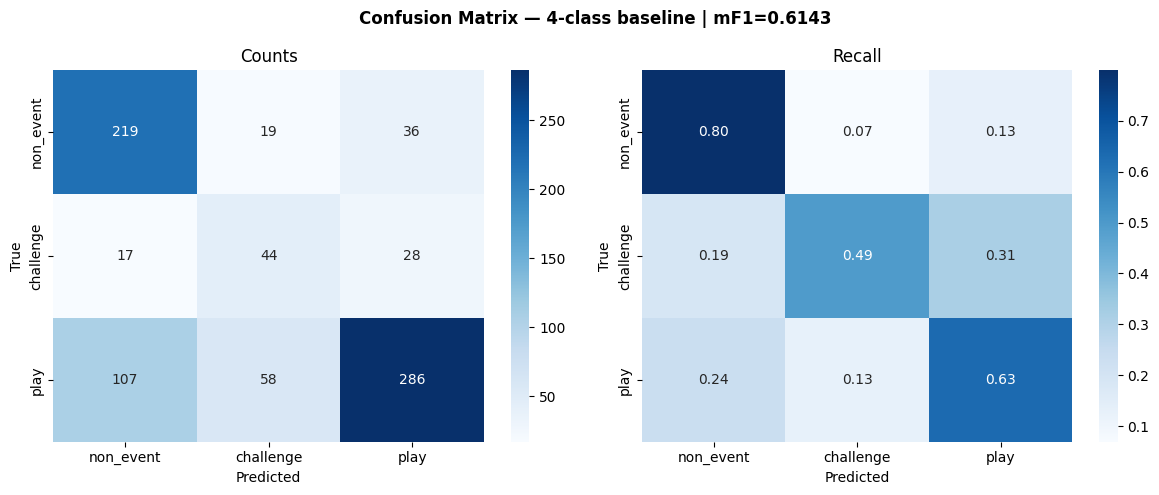

Saved → 3class_collapsed_confusion.png


In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm   = confusion_matrix(tl, test_preds)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

for ax, d, fmt, title in [
    (axes[0], cm,   "d",   "Counts"),
    (axes[1], cm_n, ".2f", "Recall"),
]:
    sns.heatmap(d, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

# Title reflects which variant was run
variant_label = ("v4 hard-neg" if (BINARY_MODE and HARD_NEG_V4)
                 else "v3 original" if BINARY_MODE
                 else "4-class baseline")
fig.suptitle(f"Confusion Matrix — {variant_label} | mF1={mf1:.4f}",
             fontsize=12, fontweight="bold")
plt.tight_layout()

# Save name uses ckpt_prefix — never overwrites other variants
fig_name = f"{ckpt_prefix}_confusion.png"
plt.savefig(RESULTS / fig_name, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {fig_name}")

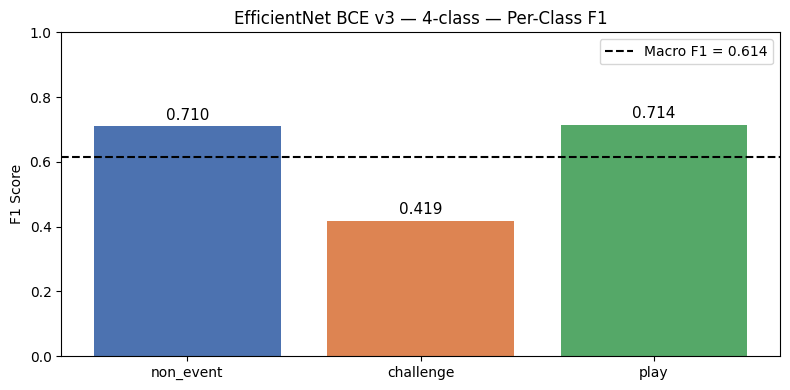

Saved → 3class_collapsed_f1bars.png


In [ ]:
# ── Per-class F1 bar chart ────────────────────────────────────────
rd  = classification_report(tl, test_preds,
                             target_names=CLASS_NAMES,
                             output_dict=True, zero_division=0)
f1s = [rd[c]["f1-score"] for c in CLASS_NAMES]

fig, ax = plt.subplots(figsize=(8, 4))
colors  = ["#4C72B0","#DD8452","#55A868","#C44E52"][:len(CLASS_NAMES)]
bars    = ax.bar(CLASS_NAMES, f1s, color=colors)

ax.axhline(y=mf1, color="black", linestyle="--",
           label=f"Macro F1 = {mf1:.3f}")
ax.set_ylim(0, 1)
ax.set_ylabel("F1 Score")

variant_label = ("v4 hard-neg gamma=2.0" if (BINARY_MODE and HARD_NEG_V4)
                 else "Binary v3: challenge vs play" if BINARY_MODE
                 else "EfficientNet BCE v3 — 4-class")
ax.set_title(f"{variant_label} — Per-Class F1")

for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", fontsize=11)
ax.legend()
plt.tight_layout()

# Save name uses ckpt_prefix — never overwrites other variants
fig_name = f"{ckpt_prefix}_f1bars.png"
plt.savefig(RESULTS / fig_name, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {fig_name}")

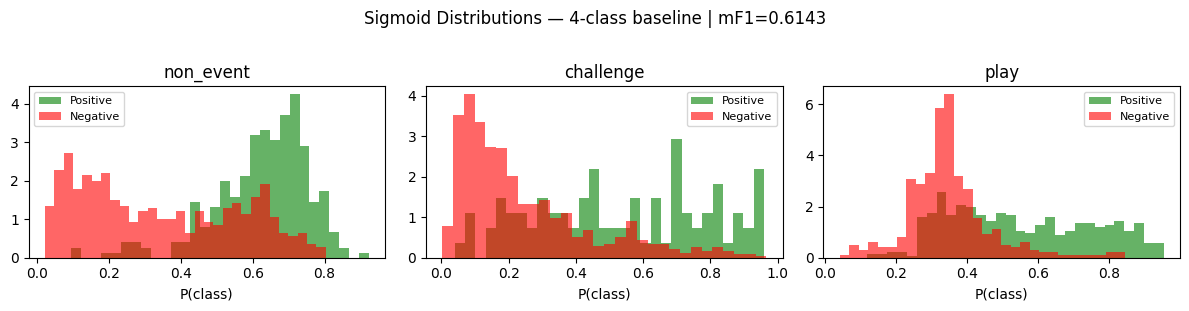

Saved → 3class_collapsed_sigmoid_dist.png


In [ ]:
# ── Sigmoid distribution per class ───────────────────────────────
probs = torch.sigmoid(test_logits).numpy()
n_cls = len(CLASS_NAMES)
fig, axes = plt.subplots(1, n_cls, figsize=(4*n_cls, 3))
if n_cls == 1:
    axes = [axes]

for i, (ax, name) in enumerate(zip(axes, CLASS_NAMES)):
    pos_mask = (tl == i)
    neg_mask = ~pos_mask
    ax.hist(probs[pos_mask, i], bins=30, alpha=0.6,
            label="Positive", color="green", density=True)
    ax.hist(probs[neg_mask, i], bins=30, alpha=0.6,
            label="Negative", color="red",   density=True)

    # Show P(ch) gap for binary mode — the key diagnostic metric
    if BINARY_MODE and i == 0:
        mu_pos = probs[pos_mask, i].mean()
        mu_neg = probs[neg_mask, i].mean()
        gap    = mu_pos - mu_neg
        ax.axvline(mu_pos, color="green", lw=2, ls="--",
                   label=f"μ⁺={mu_pos:.3f}")
        ax.axvline(mu_neg, color="red",   lw=2, ls="--",
                   label=f"μ⁻={mu_neg:.3f}")
        ax.set_title(f"{name}\ngap={gap:.3f} "
                     f"{'↑ vs v3 0.186' if gap>0.186 else '↓ vs v3 0.186'}")
    else:
        ax.set_title(name)

    ax.set_xlabel("P(class)")
    ax.legend(fontsize=8)

variant_label = ("v4 hard-neg gamma=2.0" if (BINARY_MODE and HARD_NEG_V4)
                 else "Binary v3" if BINARY_MODE
                 else "4-class baseline")
plt.suptitle(
    f"Sigmoid Distributions — {variant_label} | mF1={mf1:.4f}",
    y=1.02)
plt.tight_layout()

fig_name = f"{ckpt_prefix}_sigmoid_dist.png"
plt.savefig(RESULTS / fig_name, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {fig_name}")

In [ ]:
# ── Fine-grained weight tuning ──
import numpy as np
from itertools import product

weight_opts = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0]

if BINARY_MODE:
    best_w, best_f1 = [1.0, 1.0], 0.0
    for wc, wp in product(weight_opts, repeat=2):
        preds = weighted_preds(val_logits, [wc, wp])
        f = f1_score(val_labels.numpy(), preds, average="macro")
        if f > best_f1:
            best_f1 = f; best_w = [wc, wp]
    print(f"Weights: ch={best_w[0]}  pl={best_w[1]}")
else:
    best_w, best_f1 = [1, 1, 1, 1], 0.0
    for wb, wc, wp, wt in product(weight_opts, repeat=4):
        preds = weighted_preds(val_logits, [wb, wc, wp, wt])
        f = f1_score(val_labels.numpy(), preds, average="macro")
        if f > best_f1:
            best_f1 = f; best_w = [wb, wc, wp, wt]
    print(f"Weights: bg={best_w[0]} ch={best_w[1]} pl={best_w[2]} th={best_w[3]}")

print(f"Val mF1: {best_f1:.4f}")

test_preds2 = weighted_preds(test_logits, best_w)
tl = test_labels.numpy()
print(f"Test mF1: {f1_score(tl, test_preds2, average='macro'):.4f}")
print(f"Test Acc: {(test_preds2 == tl).mean():.1%}")
print(classification_report(tl, test_preds2,
                             target_names=CLASS_NAMES, digits=3, zero_division=0))

RuntimeError: The size of tensor a (3) must match the size of tensor b (4) at non-singleton dimension 1

In [ ]:
# ── Mean sigmoid by true class ──
probs = torch.sigmoid(test_logits).numpy()
print("Mean sigmoid by true class:")

# Header
header = f"{'True class':<12}" + "".join(f" {f'P({n[:2]})':>6}" for n in CLASS_NAMES)
print(header)
print("-" * len(header))

for i, name in enumerate(CLASS_NAMES):
    mask = (tl == i)
    row  = probs[mask].mean(axis=0)
    print(f"{name:<12}" + "".join(f" {v:>6.3f}" for v in row))

In [ ]:
# ── TTA (horizontal flip) ──
def predict_tta(mdl, dl):
    logits_all, labels_all = [], []
    with torch.no_grad():
        for x, y in tqdm(dl, desc="TTA"):
            l1 = mdl(x.to(DEVICE)).cpu()
            l2 = mdl(x.flip(-1).to(DEVICE)).cpu()
            logits_all.append((l1 + l2) / 2)
            labels_all.append(y)
    return torch.cat(logits_all), torch.cat(labels_all)

val_tta,  val_lab_tta  = predict_tta(model, dm.val_dataloader())
test_tta, test_lab_tta = predict_tta(model, dm.test_dataloader())

# ── Re-tune weights on TTA logits ──
weight_opts = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0]

if BINARY_MODE:
    best_w_tta, best_f1_tta = [1.0, 1.0], 0.0
    for wc, wp in product(weight_opts, repeat=2):
        preds = weighted_preds(val_tta, [wc, wp])
        f = f1_score(val_lab_tta.numpy(), preds, average="macro")
        if f > best_f1_tta:
            best_f1_tta = f; best_w_tta = [wc, wp]
else:
    best_w_tta, best_f1_tta = [1, 1, 1, 1], 0.0
    for wb, wc, wp, wt in product(weight_opts, repeat=4):
        preds = weighted_preds(val_tta, [wb, wc, wp, wt])
        f = f1_score(val_lab_tta.numpy(), preds, average="macro")
        if f > best_f1_tta:
            best_f1_tta = f; best_w_tta = [wb, wc, wp, wt]

test_preds_tta = weighted_preds(test_tta, best_w_tta)
tl_tta = test_lab_tta.numpy()
mf1_tta = f1_score(tl_tta, test_preds_tta, average="macro")
acc_tta = (test_preds_tta == tl_tta).mean()

print(f"TTA weights: {best_w_tta}  (val={best_f1_tta:.4f})")
print(f"Test mF1 : {mf1_tta:.4f} | Acc: {acc_tta:.1%}")
print(classification_report(tl_tta, test_preds_tta,
                             target_names=CLASS_NAMES, digits=3, zero_division=0))

In [ ]:
if not BINARY_MODE:
    # Load 512 logits
    tensors_512 = torch.load(RESULTS / "effnet_bce_v2_tensors.pt", weights_only=False)

    p1024 = torch.sigmoid(test_logits)
    p512 = torch.sigmoid(tensors_512["logits"])

    best_alpha, best_blend_f1 = 0.5, 0
    for alpha in np.arange(0.3, 0.9, 0.05):
        blended = alpha * p1024 + (1 - alpha) * p512
        for wb, wc, wp, wt in product([0.5, 1.0, 1.5, 2.0, 3.0, 5.0], repeat=4):
            adj = blended * torch.tensor([wb, wc, wp, wt]).unsqueeze(0)
            preds = adj.argmax(1).numpy()
            f = f1_score(tl, preds, average="macro")
            if f > best_blend_f1:
                best_blend_f1 = f; best_alpha = alpha; best_blend_w = [wb, wc, wp, wt]

    print(f"Best alpha={best_alpha:.2f} weights={best_blend_w}")
    print(f"Blended test mF1: {best_blend_f1:.4f}")
else:
    print("Binary mode — skipping 512 blend cell")

In [ ]:
train_preds_1024 = weighted_preds(train_logits, best_w)
tr_mf1 = f1_score(train_labels.numpy()[:len(train_preds_1024)], train_preds_1024, average="macro")
print(f"Train mF1: {tr_mf1:.4f} | Test mF1: {mf1:.4f} | Gap: {(tr_mf1-mf1)*100:.1f}%")

In [ ]:
# ── Baseline-only cells: skip in binary mode ──
if not BINARY_MODE:

    # ── 512 + 1024 blend ──
    tensors_512 = torch.load(RESULTS / "effnet_bce_v2_tensors.pt", weights_only=False)
    p1024 = torch.sigmoid(test_logits)
    p512  = torch.sigmoid(tensors_512["logits"])

    best_alpha, best_blend_f1, best_blend_w = 0.5, 0, [1,1,1,1]
    for alpha in np.arange(0.3, 0.9, 0.05):
        blended = alpha * p1024 + (1 - alpha) * p512
        for wb, wc, wp, wt in product([0.5, 1.0, 1.5, 2.0, 3.0, 5.0], repeat=4):
            adj   = blended * torch.tensor([wb, wc, wp, wt]).unsqueeze(0)
            preds = adj.argmax(1).numpy()
            f = f1_score(tl, preds, average="macro")
            if f > best_blend_f1:
                best_blend_f1 = f; best_alpha = alpha; best_blend_w = [wb, wc, wp, wt]
    print(f"Best alpha={best_alpha:.2f} weights={best_blend_w}")
    print(f"Blended test mF1: {best_blend_f1:.4f}")

    # ── Train/test gap ──
    train_preds_1024 = weighted_preds(train_logits, best_w)
    tr_mf1 = f1_score(train_labels.numpy()[:len(train_preds_1024)],
                      train_preds_1024, average="macro")
    print(f"Train mF1: {tr_mf1:.4f} | Test mF1: {mf1:.4f} | "
          f"Gap: {(tr_mf1-mf1)*100:.1f}%")

    # ── Feature extraction ──
    print("Extracting 64-d features...")
    feat_dict = {}
    feat_ds = FrameDataset(clips, CACHE, ram_cache, augment=False)
    feat_dl = DataLoader(feat_ds, batch_size=BATCH, num_workers=NW)
    fi = 0
    model.eval()
    with torch.no_grad():
        for x, _ in tqdm(feat_dl, desc="Features"):
            feats = model.extract_features(x.to(DEVICE)).cpu()
            for j in range(feats.shape[0]):
                if fi >= len(clips): break
                feat_dict[clips[fi]["name"]] = {
                    "features":   feats[j],
                    "label":      clips[fi]["label"],
                    "label_name": clips[fi]["label_name"],
                }
                fi += 1
    fp = FEAT_DIR / "effnet_bce_1024_features.pt"
    torch.save(feat_dict, fp)
    print(f"Saved: {len(feat_dict)} clips → {fp.name}")

else:
    print("Binary mode — skipping blend, gap, and feature extraction cells.")

## Summary

**Changes from baseline → 1st place replication:**

| Change | Source | Expected gain |
|---|---|---|
| BCE with 3 sigmoids (not softmax) | 5th place ablation | +0.085 |
| 1024×1024 resolution | 1st place config | +0.02-0.04 |
| Full augmentation (affine, color, erasing) | 5th place ablation | +0.07 |
| Mixup alpha 0.4 | 1st/3rd place | regularisation |
| sqrt(neg/pos) pos_weight per class | class balance | minority boost |
| Frozen early layers + no_grad | memory optimisation | enables batch 16 |

**Outputs:**

| File | Location |
|---|---|
| `effnet_bce-*.ckpt` | checkpoints/ |
| `effnet_bce_result.json` | results_effnet/ |
| `effnet_bce_test_tensors.pt` | results_effnet/ |
| `effnet_bce_features.pt` | features/ |
| `effnet_bce_confusion.png` | results_effnet/ |

**Next:** Build ensemble notebook with CLIP 512-d + EfficientNet 64-d features.